# 01 - Exploratory Data Analysis

**Phase 1 (Weeks 1-2)** of the Portuguese wildfire catastrophe loss model.

This notebook loads a real per-fire wildfire database for Portugal and
explores the resulting frequency and severity patterns.

See `docs/phase1-plan.md` and `docs/worklog.md` in the repo root for the
full data-sourcing story. In short:

- The primary data source is EFFIS's own Rapid Damage Assessment (MODIS-
  based) fire database, obtained via EFFIS's official Data Request Form
  (a one-time manual submission, since EFFIS's live Statistics Portal has
  no public JSON API). This gives real per-fire dates, real NUTS2 region
  locations, and real burned areas for mainland Portugal, 2010-2024.
- The MODIS-era product maps fires of roughly 30 ha or larger (per EFFIS's
  own documentation), an estimated 75-80% of total burnt area despite being
  a minority of total fire count. From 2019 the export switches to
  Sentinel-2 and includes fires down to 1 ha, so **a "fire event" in this
  model means a mapped fire of at least 30 ha, applied explicitly and
  uniformly to every year** (`MIN_FIRE_AREA_HA`), not every ignition and not
  whatever each sensor happened to map - see "Why the size threshold is
  applied explicitly" below.
- No public source publishes verified EUR loss per individual fire. A
  documented EUR/ha calibration constant (derived from published ICNF/OECD
  aggregate figures) is applied to real burned areas instead.
- Live OWID/GWIS annual aggregates are still fetched, but only as an
  independent cross-check against the real per-fire data, not as a
  modeling input. See "Data gaps and assumptions" below for what that
  cross-check found.

## Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests

from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY = "Portugal"
MAX_YEAR = 2024  # freeze scope to the PRD window; excludes the still-in-progress current season
# EFFIS mapped fires below this size are not comparable across the whole window: the
# mapping source changes from MODIS (2010-2018, ~20 ha minimum) to Sentinel-2 (2020-2024,
# down to 1 ha), so raw counts are not a stationary series. Applied uniformly to every year.
MIN_FIRE_AREA_HA = 30


## Data loading

`load_effis_fire_database` reads the real, committed per-fire snapshot
(the primary data source). `fetch_annual_fire_counts` and
`fetch_annual_burnt_area` pull live OWID/GWIS aggregates used only for
cross-validation further down, not as modeling inputs.

In [2]:
def load_effis_fire_database(path: Path = RAW_DIR / "effis_fire_database_pt_2010_2024.csv",
                             min_area_ha: float = MIN_FIRE_AREA_HA,
                             mainland_only: bool = True) -> pd.DataFrame:
    """Load the real per-fire EFFIS Rapid Damage Assessment database for Portugal.

    Source: EFFIS's official Data Request Form (forest-fire.emergency.
    copernicus.eu/apps/data.request.form/), dataset "Burnt area mapped
    using Sentinel2/MODIS images", Portugal, 2010-01-01 to 2024-12-31.
    Obtained as a one-time manual submission (not a live API), so this
    file is a static, committed snapshot rather than something re-fetched
    on each run - no reproducibility drift risk for this component.

    Per EFFIS's own documentation (see the accompanying .readme.txt in
    data/raw/), this product maps fires of roughly 30 ha or larger, which
    still represents an estimated 75-80% of Portugal's total burnt area
    despite being a minority of total fire count. That only holds for the
    MODIS-era records (2010-2018): from 2019 the export's `map_source`
    switches to Sentinel-2 and records as small as 1 ha appear (62-82% of
    2020-2024 rows are under 30 ha), which would make annual counts ~3x
    higher for a sensor reason, not a hazard reason. Four cleaning steps
    are therefore applied. First, records outside mainland Portugal
    (`admlvl1` other than "Continente": 44 Madeira and 4 Azores rows in the
    raw export) are dropped, since the model's scope is mainland only and
    Madeira/Azores behave differently. Then: ~40 of 6,608 raw records with area_ha <= 0 are dropped as
    non-physical mapping artifacts (EFFIS's own caveats about small/
    unmapped islands within a burn scar), and 69 exact duplicate records
    (same parish, area, and timestamp logged under a different id, ~104 ha
    total, concentrated in 2021-2024) are deduplicated as a confirmed
    export artifact - see docs/worklog.md for how this was found. Finally,
    only fires of at least `min_area_ha` are kept (default
    MIN_FIRE_AREA_HA = 30), so frequency and severity are defined on the
    same size threshold in every year.

    Parameters
    ----------
    path : Path
        Location of the committed raw EFFIS export.
    min_area_ha : float
        Minimum burned area for a record to count as a fire event.
    mainland_only : bool
        Keep only mainland Portugal (`admlvl1 == "Continente"`).

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha - one row per real mapped
        fire event, sorted by date.
    """
    df = pd.read_csv(path, encoding="utf-8")
    if mainland_only:
        df = df[df["admlvl1"] == "Continente"]
    df["Date"] = pd.to_datetime(df["initialdate"], format="mixed")
    df = df[df["area_ha"] > 0]
    df = df.drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"], keep="first")
    df = df[df["area_ha"] >= min_area_ha]

    result = df.rename(columns={"admlvl2": "Location", "area_ha": "Burned_Area_ha"})
    return result[["Date", "Location", "Burned_Area_ha"]].sort_values("Date").reset_index(drop=True)

### Why the size threshold is applied explicitly

The export's mapping source changes over time, and the smallest mapped fire
changes with it. The table below is computed from the raw file before any
size filter.


In [3]:
raw = pd.read_csv(RAW_DIR / "effis_fire_database_pt_2010_2024.csv", encoding="utf-8")
raw = raw[raw["admlvl1"] == "Continente"]  # mainland only, as in load_effis_fire_database
raw["year"] = pd.to_datetime(raw["initialdate"], format="mixed").dt.year
raw = raw[raw["area_ha"] > 0].drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"])

mapping_break = raw.groupby("year").agg(
    map_source=("map_source", lambda s: "/".join(sorted(s.unique()))),
    records=("area_ha", "size"),
    min_area_ha=("area_ha", "min"),
    pct_under_threshold=("area_ha", lambda a: (a < MIN_FIRE_AREA_HA).mean() * 100),
).round(1)
print(mapping_break)

before = raw.groupby("year").size()
after = raw[raw["area_ha"] >= MIN_FIRE_AREA_HA].groupby("year").size()
print()
print(f"Mean records/year, unfiltered:   2010-2019 {before.loc[:2019].mean():.0f}   2020-2024 {before.loc[2020:].mean():.0f}")
print(f"Mean records/year, >= {MIN_FIRE_AREA_HA} ha:      2010-2019 {after.loc[:2019].mean():.0f}   2020-2024 {after.loc[2020:].mean():.0f}")


           map_source  records  min_area_ha  pct_under_threshold
year                                                            
2010            modis      305           20                  4.9
2011            modis      319           20                  5.0
2012            modis      235           15                  5.1
2013            modis      359           12                  9.2
2014            modis       35           24                  2.9
2015            modis      177           16                  4.5
2016            modis      320           19                  3.1
2017            modis      411           22                  1.5
2018            modis       86           20                  9.3
2019  modis/sentinel2      217           21                 22.6
2020        sentinel2      462            1                 62.8
2021        sentinel2      745            1                 74.9
2022        sentinel2     1204            1                 78.7
2023        sentinel2    

In [4]:
def fetch_annual_fire_counts(country: str = COUNTRY,
                              save_path: Path = RAW_DIR / "effis_annual_fire_counts.csv") -> pd.DataFrame:
    """Fetch annual wildfire counts for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS (Global Wildfire Information
    System, JRC/Copernicus) annual fire-count series, VIIRS/MODIS-detection
    based and covering *all* fire sizes. Not used as the model's frequency
    source (see load_effis_fire_database) - kept only to cross-check
    against the real large-fire-only counts, since the two series measure
    different things and are not expected to reconcile (see "Data gaps and
    assumptions").

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, fire_count (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-number-of-fires.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Annual number of fires": "fire_count"}
    )
    return df[["year", "fire_count"]].sort_values("year").reset_index(drop=True)

In [5]:
def fetch_annual_burnt_area(country: str = COUNTRY,
                             save_path: Path = RAW_DIR / "gwis_annual_burnt_area.csv") -> pd.DataFrame:
    """Fetch annual burnt area (hectares) for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS's MODIS-derived annual
    burnt-area-by-region series, covering *all* fire sizes. Used below to
    check what share of total burnt area the real large-fire-only dataset
    captures, not as a modeling input.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, burnt_area_ha (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-area-burnt-by-wildfires-gwis.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Yearly burned area across all land types": "burnt_area_ha"}
    )
    return df[["year", "burnt_area_ha"]].sort_values("year").reset_index(drop=True)

In [6]:
def build_loss_calibration(area_2017_ha: float,
                           anchors_path: Path = RAW_DIR / "loss_anchors.csv",
                           save_path: Path = RAW_DIR / "annual_loss_calibration.csv") -> pd.DataFrame:
    """Build (and persist) the low / central / high EUR/ha loss scenarios.

    No public source publishes verified EUR loss per individual fire, and
    published totals for the same event differ by roughly an order of
    magnitude per hectare depending on what they include. So EUR/ha is
    carried as a three-point range, not a single calibrated constant. The
    evidence behind each point is in data/raw/loss_anchors.csv:

    - low: 2024 forest-sector loss (EUR 67m, AGIF) over 2024 national
      burnt area (137,667 ha), ~EUR 487/ha. A component of loss, so a
      floor for direct damage, not a total.
    - central: ICNF-derived long-run 1975-2021 average, ~EUR 10bn over
      ~5.2M ha (~EUR 1,923/ha), via OECD/press reporting. Weakest source
      of the three, and 2017 is part of its numerator.
    - high: the 2017 season's EU Solidarity Fund total direct damage
      (EUR 1,458m) over the 2017 mainland burnt area in this dataset.
      Same area basis as the model, so numerator and denominator agree.

    Parameters
    ----------
    area_2017_ha : float
        2017 mainland burnt area (ha) in the model dataset, the denominator
        for the high scenario.
    anchors_path : Path
        The anchors evidence table.
    save_path : Path
        Where to save the scenario table.

    Returns
    -------
    pd.DataFrame
        Columns: label, eur_per_ha, source.
    """
    anchors = pd.read_csv(anchors_path).set_index("anchor_id")
    calibration = pd.DataFrame([
        {
            "label": "low",
            "eur_per_ha": anchors.loc["pt_2024_forest", "damage_eur"] / anchors.loc["pt_2024_forest", "area_ha"],
            "source": "2024 forest-sector loss (AGIF) / 2024 national burnt area; a floor, not a total",
        },
        {
            "label": "central",
            "eur_per_ha": 10_000_000_000 / 5_200_000,
            "source": "ICNF cumulative 1975-2021 burnt area & losses, via OECD/press reporting",
        },
        {
            "label": "high",
            "eur_per_ha": anchors.loc["pt_2017_total", "damage_eur"] / area_2017_ha,
            "source": "2017 EU Solidarity Fund total direct damage / 2017 mainland burnt area in this dataset",
        },
    ])
    save_path.write_text(calibration.to_csv(index=False), encoding="utf-8")
    return calibration


## Plotting functions

In [7]:
def plot_annual_fire_counts(df: pd.DataFrame, date_col: str = "Date", ax=None):
    """Plot a bar chart of fire occurrence counts by year.

    Parameters
    ----------
    df : pd.DataFrame
        Fire occurrence data with a date column.
    date_col : str
        Name of the column containing event dates.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    counts = df[date_col].dt.year.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fire count")
    ax.set_title("Annual fire occurrence counts")
    return ax

In [8]:
def plot_loss_histogram(df: pd.DataFrame, loss_col: str = "Estimated_Loss_EUR", bins: int = 50, ax=None):
    """Plot a histogram of per-event loss magnitude.

    Parameters
    ----------
    df : pd.DataFrame
        Loss data with a numeric loss column.
    loss_col : str
        Name of the column containing loss amounts.
    bins : int
        Number of histogram bins.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(df[loss_col], bins=bins)
    ax.set_xlabel("Estimated loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss magnitude distribution")
    return ax

In [9]:
def plot_empirical_cdf(data: np.ndarray, ax=None, label: str = "Empirical"):
    """Plot the empirical CDF of a 1D numeric array.

    Parameters
    ----------
    data : np.ndarray
        Sample values (e.g. per-event losses or annual counts).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for this CDF curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label)
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax

## Run EDA

In [10]:
processed_df = load_effis_fire_database()
area_2017_ha = processed_df.loc[processed_df["Date"].dt.year == 2017, "Burned_Area_ha"].sum()
calibration_df = build_loss_calibration(area_2017_ha)

eur_per_ha = calibration_df.loc[calibration_df["label"] == "central", "eur_per_ha"].iloc[0]
processed_df["Estimated_Loss_EUR"] = processed_df["Burned_Area_ha"] * eur_per_ha
processed_df.to_csv(PROCESSED_DIR / "wildfires_processed.csv", index=False)

print(f"Years covered: {processed_df['Date'].dt.year.min()}-{processed_df['Date'].dt.year.max()}")
print(f"Total real fire events: {len(processed_df)}")
print(f"EUR/ha scenarios (low / central / high): " + " / ".join(f"{v:,.0f}" for v in calibration_df["eur_per_ha"]))
print(f"Central scenario applied to Estimated_Loss_EUR: EUR {eur_per_ha:,.0f} / ha")
print(f"NaN check: {processed_df.isna().sum().sum()} missing values")
processed_df.head()

Years covered: 2010-2024
Total real fire events: 3263
EUR/ha scenarios (low / central / high): 487 / 1,923 / 2,593
Central scenario applied to Estimated_Loss_EUR: EUR 1,923 / ha
NaN check: 0 missing values


,Date,Location,Burned_Area_ha,Estimated_Loss_EUR
0,2010-03-13,Norte,73,1.403846e+05
1,2010-04-10,Norte,288,5.538462e+05
2,2010-04-14,Norte,289,5.557692e+05
3,2010-05-04,Norte,530,1.019231e+06
4,2010-05-05,Norte,53,1.019231e+05


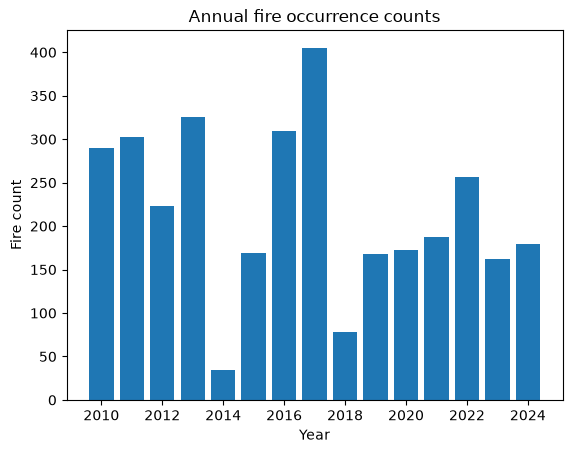

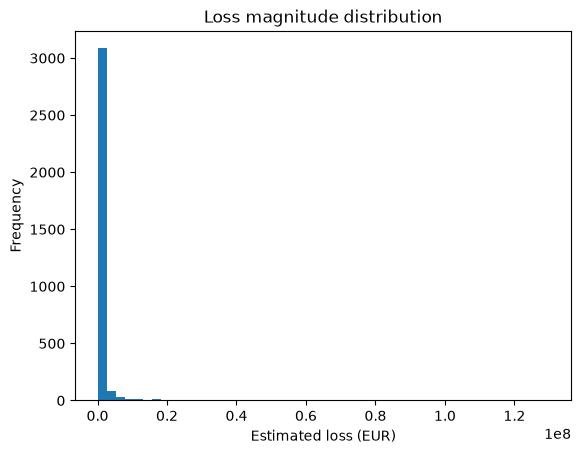

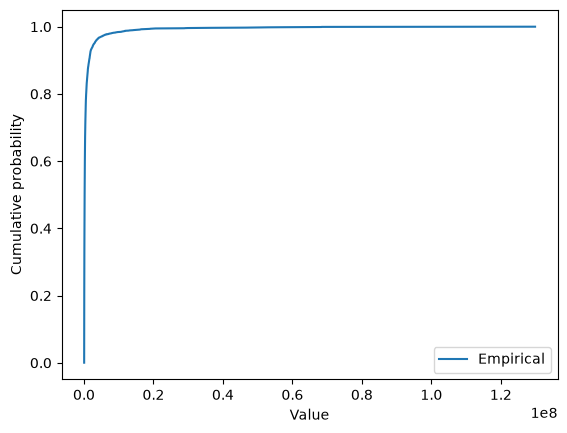

In [11]:
plot_annual_fire_counts(processed_df)
plt.show()

plot_loss_histogram(processed_df)
plt.show()

plot_empirical_cdf(processed_df["Estimated_Loss_EUR"].values)
plt.show()

## Cross-validation against independent aggregate sources

Compares the real large-fire dataset against live OWID/GWIS annual
aggregates (all fire sizes), as an independent sanity check rather than a
reconciliation - the two sources measure different things (see "Data gaps
and assumptions").

In [12]:
owid_counts = fetch_annual_fire_counts()
owid_counts = owid_counts[owid_counts["year"] <= MAX_YEAR]
gwis_area = fetch_annual_burnt_area()
gwis_area = gwis_area[gwis_area["year"] <= MAX_YEAR]

real_annual = processed_df.groupby(processed_df["Date"].dt.year).agg(
    real_large_fire_count=("Burned_Area_ha", "size"),
    real_large_fire_area_ha=("Burned_Area_ha", "sum"),
)
real_annual.index.name = "year"

comparison = real_annual.join(owid_counts.set_index("year")).join(gwis_area.set_index("year"))
comparison["large_fire_vs_gwis_ratio_pct"] = (
    comparison["real_large_fire_area_ha"] / comparison["burnt_area_ha"] * 100
)
print(comparison)
print()

def area_ratio(frame):
    return frame["real_large_fire_area_ha"].sum() / frame["burnt_area_ha"].sum() * 100

total_ratio = area_ratio(comparison)
early_ratio = area_ratio(comparison.loc[:2019])
recent_ratio = area_ratio(comparison.loc[2020:])
n_count_exceed = int((comparison["real_large_fire_count"] > comparison["fire_count"]).sum())
n_count_years = int(comparison["fire_count"].notna().sum())

print(f"Total-to-total area ratio, all years (properly weighted): {total_ratio:.1f}%")
print(f"  2010-2019: {early_ratio:.1f}%    2020-2024: {recent_ratio:.1f}%")
print("A simple mean of per-year ratios would overstate the disagreement, since it weights")
print("small years (e.g. 2021) the same as large ones (e.g. 2017).")
print()
print(f"Years where the >= {MIN_FIRE_AREA_HA} ha count exceeds OWID's all-fire count: {n_count_exceed} of {n_count_years}")
print()

rolling = comparison[["real_large_fire_area_ha", "burnt_area_ha"]].rolling(3).sum().dropna()
rolling["ratio_3yr_pct"] = rolling["real_large_fire_area_ha"] / rolling["burnt_area_ha"] * 100
print("3-year rolling ratio (smooths out single-year noise):")
print(rolling["ratio_3yr_pct"].round(0).astype(int))


      real_large_fire_count  real_large_fire_area_ha  fire_count  \
year                                                               
2010                    290                   120693         NaN   
2011                    303                    64442         NaN   
2012                    223                    95379       815.0   
2013                    326                   153408      1143.0   
2014                     34                    11550       175.0   
2015                    169                    47286       600.0   
2016                    310                   160444       975.0   
2017                    405                   562348      1365.0   
2018                     78                    37144       209.0   
2019                    168                    33181       359.0   
2020                    172                    61280       323.0   
2021                    187                    25855       284.0   
2022                    257                   10

## Domain validation: order-of-magnitude sanity check

Per the PRD's Domain Validation criterion, checked here early rather than
waiting for Phase 4: does the modeled annual loss land in the right ballpark
for well-documented years? Now on real per-fire data, this is a genuine
test of the calibration constant, not just the synthesis method.

In [13]:
annual_modeled_loss = processed_df.groupby(processed_df["Date"].dt.year)["Estimated_Loss_EUR"].sum()
print(annual_modeled_loss.map(lambda x: f"EUR {x:,.0f}"))

# Published benchmarks (sourced, see data/raw/published_loss_benchmarks.csv)
bench = pd.read_csv(RAW_DIR / "published_loss_benchmarks.csv").set_index("measure")
modeled_2024 = annual_modeled_loss.loc[2024]
model_area_2024 = processed_df.loc[processed_df["Date"].dt.year == 2024, "Burned_Area_ha"].sum()
agif_area = bench.loc["burnt_area_agif", "value"]
forest = bench.loc["forest_sector_loss", "value"]
insured = bench.loc["insured_claims_provisional", "value"]

print()
print("2024 area check, mainland (independent of the EUR calibration):")
print(f"  EFFIS mainland >= {MIN_FIRE_AREA_HA} ha: {model_area_2024:,.0f} ha  vs  AGIF: {agif_area:,.0f} ha  ({model_area_2024 / agif_area:.1%})")
print()
print("2024 loss comparison (modeled total vs the only euro figures found):")
print(f"  Modeled total, central EUR {eur_per_ha:,.0f}/ha:     EUR {modeled_2024 / 1e6:,.0f}m")
print(f"  Forest-sector loss only (AGIF):         EUR {forest / 1e6:,.0f}m  = {forest / modeled_2024:.0%} of modeled; implies EUR {forest / agif_area:,.0f}/ha")
print(f"  + insured claims, Sep fires (APS):      EUR {(forest + insured) / 1e6:,.0f}m  = {(forest + insured) / modeled_2024:.0%} of modeled")
print("  These are components of loss, not a total: they exclude uninsured homes and businesses,")
print("  agriculture, public infrastructure and firefighting cost. No published TOTAL economic loss")
print("  for 2023 or 2024 was found, so the PRD's 'within ~20% of published reports' test cannot")
print("  be run for those years. The modeled figure is above the measured floor, as it should be,")
print("  but that is a bracket, not a validation.")
print()
print("2017 against the official EU Solidarity Fund total (EUR 1,458m, mainland season):")
area_by_year = processed_df.groupby(processed_df["Date"].dt.year)["Burned_Area_ha"].sum()
scen = pd.DataFrame(
    {row.label: area_by_year * row.eur_per_ha / 1e6 for row in calibration_df.itertuples()}
).loc[[2017, 2023, 2024]].round(0)
scen.columns = [f"{c} (EUR m)" for c in scen.columns]
print(scen)
official_2017 = pd.read_csv(RAW_DIR / "loss_anchors.csv").set_index("anchor_id").loc["pt_2017_total", "damage_eur"]
central_2017 = area_by_year.loc[2017] * eur_per_ha
print(f"  central scenario gives {central_2017 / official_2017:.0%} of the official 2017 total; the high scenario matches it by construction.")
print("  The central figure is not calibrated to 2017, but 2017 is ~15% of its long-run numerator, so this")
print("  is only a partly independent check. What it shows is the size of the non-linearity (2017 per-ha")
print(f"  damage ~{calibration_df.loc[calibration_df['label'] == 'high', 'eur_per_ha'].iloc[0] / eur_per_ha:.1f}x the long-run average).")
print()
print("Other reference points:")
print("  2022 Serra da Estrela fire (EMSR618): ~25,000 ha; 2024 Central Madeira fire (EMSR748): >5,000 ha")
print("  (both from earlier research, not re-verified; EMSR748 is Madeira and outside the mainland scope).")
print(f"  Copernicus EMS, Sept 2024 mainland fires: {bench.loc['ems_burnt_area_all_activations', 'value']:,.1f} ha across 4 areas of interest;")
print(f"  EMSR760 (Sever do Vouga) alone: {bench.loc['ems_emsr760_burnt_area', 'value']:,.1f} ha.")
top2024 = processed_df[processed_df["Date"].dt.year == 2024].nlargest(1, "Burned_Area_ha").iloc[0]
print(f"  Largest 2024 record here: {top2024['Burned_Area_ha']:,.0f} ha ({top2024['Location']}, {top2024['Date']:%Y-%m-%d}).")
print("  That exceeds EMSR760's 21,262 ha, so it cannot be that activation's perimeter as-is; it may merge")
print("  adjacent fires or be a different fire. Not confirmed either way.")


Date
2010      EUR 232,101,923
2011      EUR 123,926,923
2012      EUR 183,421,154
2013      EUR 295,015,385
2014       EUR 22,211,538
2015       EUR 90,934,615
2016      EUR 308,546,154
2017    EUR 1,081,438,462
2018       EUR 71,430,769
2019       EUR 63,809,615
2020      EUR 117,846,154
2021       EUR 49,721,154
2022      EUR 200,651,923
2023       EUR 59,717,308
2024      EUR 264,546,154
Name: Estimated_Loss_EUR, dtype: str

2024 area check, mainland (independent of the EUR calibration):
  EFFIS mainland >= 30 ha: 137,564 ha  vs  AGIF: 137,667 ha  (99.9%)

2024 loss comparison (modeled total vs the only euro figures found):
  Modeled total, central EUR 1,923/ha:     EUR 265m
  Forest-sector loss only (AGIF):         EUR 67m  = 25% of modeled; implies EUR 487/ha
  + insured claims, Sep fires (APS):      EUR 84m  = 32% of modeled
  These are components of loss, not a total: they exclude uninsured homes and businesses,
  agriculture, public infrastructure and firefighting cost. No pub

## Data gaps and assumptions

**Frequency and severity data (real, per-fire):**
- Source: EFFIS's Rapid Damage Assessment (MODIS-based) fire database,
  obtained via EFFIS's official Data Request Form as a one-time manual
  submission for Portugal, 2010-01-01 to 2024-12-31. This is a static
  file committed to `data/raw/`, not a live API - no reproducibility
  drift risk for this component.
- **Scope: mainland Portugal, a mapped fire of at least 30 ha, applied
  explicitly.** EFFIS's documentation says the MODIS product maps fires of
  roughly 30 ha or larger (an estimated 75-80% of burnt area). That holds
  for 2010-2018, but the export's `map_source` becomes `modis/sentinel2` in
  2019 and `sentinel2` from 2020, and the smallest mapped fire drops from
  ~12-24 ha to 1 ha: 63-82% of 2020-2024 rows are under 30 ha versus
  1.5-9% in 2010-2018. Unfiltered, mean annual counts jump from ~246
  (2010-2019) to ~804 (2020-2024) for a sensor reason, not a hazard reason.
  An explicit `MIN_FIRE_AREA_HA = 30` filter is applied to every year,
  which keeps 98.2% of mapped area and gives 231 vs 191 mean events/year
  for 2010-2019 vs 2020-2024, i.e. no upward trend. This is a deliberate
  scope choice for a tail-risk model, and it keeps frequency and severity
  defined on one consistent threshold.
- **Cleaning waterfall:** 6,608 raw records -> 6,560 mainland (48 Madeira
  and Azores records dropped, since the model is mainland-only) -> 6,520
  with area > 0 (40 non-physical records dropped; EFFIS's own notes mention
  small/unmapped islands within a burn scar) -> 6,485 after removing 35
  redundant duplicate copies (same parish, area and timestamp under a
  different `id`; 69 rows sit in duplicate sets, 35 are the extra copies;
  all 1-12 ha, ~104 ha in total, concentrated in 2021-2024) -> **3,263
  events at >= 30 ha** (3,222 below 30 ha dropped).
- **Count discrepancy vs OWID: resolved.** An earlier pass found EFFIS
  large-fire counts *exceeding* OWID's all-fire counts (e.g. 2022: 1,204
  unfiltered vs 465) and attributed it to MODIS-vs-VIIRS methodology. The
  real cause was the unfiltered Sentinel-2 records described above: with
  the 30 ha filter the EFFIS count (257 in 2022) is below OWID's in every
  year with OWID data (0 of 13 exceed it).
- **Area discrepancy vs GWIS: narrowed, not closed.** An earlier "mean
  ratio" of 116.6% was misleading (an unweighted mean over-weights small
  years). The weighted total-to-total ratio is 104.1% unfiltered and
  **102.2%** with the 30 ha filter. By period, the filtered ratio is 100.7%
  for 2010-2019 and 108.1% for 2020-2024 (116.0% unfiltered), so the
  sub-30 ha records explain about half of the recent-years excess and an
  ~8% overshoot remains. Not caused by the duplicate records; candidate
  causes not yet checked are GWIS's most recent years being less finalized,
  Sentinel-2 10 m perimeters delineating burn scars differently from 250 m
  MODIS, and whether GWIS's "Portugal" includes the islands (which would
  make the mainland ratio slightly understated). Small enough not to change
  the model's conclusions; left as a documented open question.
- **Frequency is strongly overdispersed.** Annual counts range from 34
  (2014) to 405 (2017) around a mean of ~218, a variance-to-mean ratio of
  ~44 where a Poisson process gives ~1. Phase 2 should expect a plain
  Poisson to fail goodness-of-fit and compare a Negative Binomial.
- **Frequency and severity are not independent, and polygons are not
  independent events.** Annual count vs median fire size: Spearman rho 0.58
  (permutation p = 0.026), holding without 2017. A model that draws counts
  and sizes independently gives an annual-area SD of ~61k ha against ~134k
  ha observed, and essentially never produces a 2017-sized year. Fires also
  cluster: on 2017-10-15, 33 polygons burned 196,476 ha (the largest single
  polygon that year is 67,521 ha), and the top 10 fire-days hold 36% of all
  area. Grouping by start date gives 1,106 fire-day events; overdispersion
  falls to ~6 and the count-size correlation is no longer significant, but
  the annual-area SD is still ~1.85x the independent value. Phase 2/3 plan:
  model fire-day events, add a year-level severity factor, and cross-check
  with a whole-year bootstrap. **To revisit:** the fire-day definition is a
  simple first choice (same start date, national scope); multi-day windows
  in the style of a treaty hours clause should be tested later.
- `Location` is the real NUTS2-level region (EFFIS's `admlvl2` field).
  Finer `admlvl3`/`admlvl5` fields exist in the raw file but are
  intentionally unused, matching the PRD's explicit exclusion of
  sub-regional/spatial granularity from scope.

**Loss calibration (EUR/ha):**
- No source publishes verified EUR loss per individual fire, and published
  totals for the same event differ by roughly an order of magnitude per
  hectare depending on what they include (Pedrogao Grande 2017: EUR 497m
  government estimate vs ~EUR 200m direct losses). EUR/ha is therefore a
  **three-point range, not a calibrated constant**: low ~487 (2024
  forest-sector loss / burnt area; a floor), central ~1,923 (ICNF-derived
  1975-2021 average via OECD/press; 2017 is ~15% of its numerator), high
  ~2,593 (2017 EU Solidarity Fund total direct damage of EUR 1,458m / the
  562,348 ha mainland area in this dataset). Evidence for each point, and
  the candidate anchors not used, are in `data/raw/loss_anchors.csv`.
- **Only one official mainland total sits inside the data window (2017).**
  Madeira 2016 (EUR 157m over 5,409 ha, ~EUR 29,000/ha, ~11x the mainland
  2017 figure, and unverified) is excluded as out of scope. 2003 (>EUR 800m
  over ~425,000 ha, ~EUR 1,900/ha) would be a second catastrophic-year
  anchor but both figures need verifying and it predates the EFFIS window.
  Ordinary years have no anchor: their EUR/ha is likely below the
  catastrophic-year values because remote forest dominates, which the low
  scenario only brackets. The 2017 EUSF total is derived by arithmetic
  (0.832% of GNI against a EUR 1,051.6m threshold at 0.6%) from figures seen
  in search results; the primary document was not opened.
- **Modeled loss is burnt area times a constant** per scenario: the loss
  distribution has exactly the shape of the area distribution, and VaR/ES in
  euros are the area VaR/ES rescaled. Best read as a burnt-area model with
  a euro scale. `Estimated_Loss_EUR` uses the central scenario.
- **External checks, and what they can and cannot show.** 2024 mainland
  burnt area agrees with AGIF (137,564 ha vs 137,667 ha, 99.9%). 2017: the
  central scenario gives EUR 1,081m, 74% of the official EUR 1,458m, a
  partly independent check since the central figure isn't calibrated to
  2017; the high scenario matches by construction. For 2024 the only
  published euro figures are components (forest-sector loss EUR 67m,
  provisional insured claims above EUR 17m, together ~EUR 84m) against a
  central-scenario total of ~EUR 265m: a bracket, not a validation, since no
  published total economic loss for 2023 or 2024 was found. The PRD's
  "within published range" test needs a defined benchmark before Phase 4.

**Superseded approach**: an earlier version of this notebook synthesized
individual fire records to match real annual aggregates, since the real
per-fire database hadn't arrived yet. That synthesis step has been fully
replaced now that real data is available - see `docs/worklog.md` for that
history.